In [1]:
import os, json, base64, mimetypes, requests, traceback
from pathlib import Path
from openai import OpenAI
from IPython.display import display, Image as IPImage

# Import the model via the RCP portal

In [3]:
BASE_URL = "https://inference.rcp.epfl.ch/v1"
MODEL = "meta-llama/Llama-4-Maverick-17B-128E-Instruct"
MAX_TOKENS = 200
TEMPERATURE = 0.0

secret_key = "replace_with_your_key"
os.environ["IMAJLLAMA"] = secret_key  
key = os.environ.get("IMAJLLAMA")
assert key, "Set IMAJLLAMA in this notebook"

client = OpenAI(api_key=key, base_url=BASE_URL)

# Test with a simple text question

In [4]:
try:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": "What is 2+2?"}],
        max_tokens=20,
        temperature=0.0,
    )
    choice = resp.choices[0]
    msg = getattr(choice, "message", None) or choice
    content = msg.get("content") if isinstance(msg, dict) else getattr(msg, "content", None)
    print("RAW RESPONSE:\n", content)
except Exception:
    traceback.print_exc()

RAW RESPONSE:
 The answer to 2 + 2 is 4.


# Test asking for an image caption

Function to convert an image to a data URL

In [4]:
def file_to_data_url(p: Path) -> str:
    b = p.read_bytes()
    mime, _ = mimetypes.guess_type(str(p))
    if not mime:
        mime = "image/jpeg"
    b64 = base64.b64encode(b).decode("ascii")
    return f"data:{mime};base64,{b64}"

def upload_try(path: Path) -> str:
    with path.open("rb") as f:
        try:
            r = requests.post("https://0x0.st", files={"file": f}, timeout=30)
            r.raise_for_status()
            return r.text.strip()
        except Exception as e:
            print("0x0.st failed:", type(e).__name__, e)

    with path.open("rb") as f:
        try:
            r = requests.post("https://file.io", files={"file": f}, timeout=30)
            r.raise_for_status()
            j = r.json()
            if j.get("link"):
                return j["link"]
            if j.get("id"):
                return "https://file.io/" + j["id"]
            print("file.io response:", j)
        except Exception as e:
            print("file.io failed:", type(e).__name__, e)
    with path.open("rb") as f:
        try:
            r = requests.put(f"https://transfer.sh/{path.name}", data=f, timeout=30, verify=False)
            r.raise_for_status()
            return r.text.strip()
        except Exception as e:
            print("transfer.sh failed:", type(e).__name__, e)
    raise RuntimeError("All uploads failed")

Test on an image file

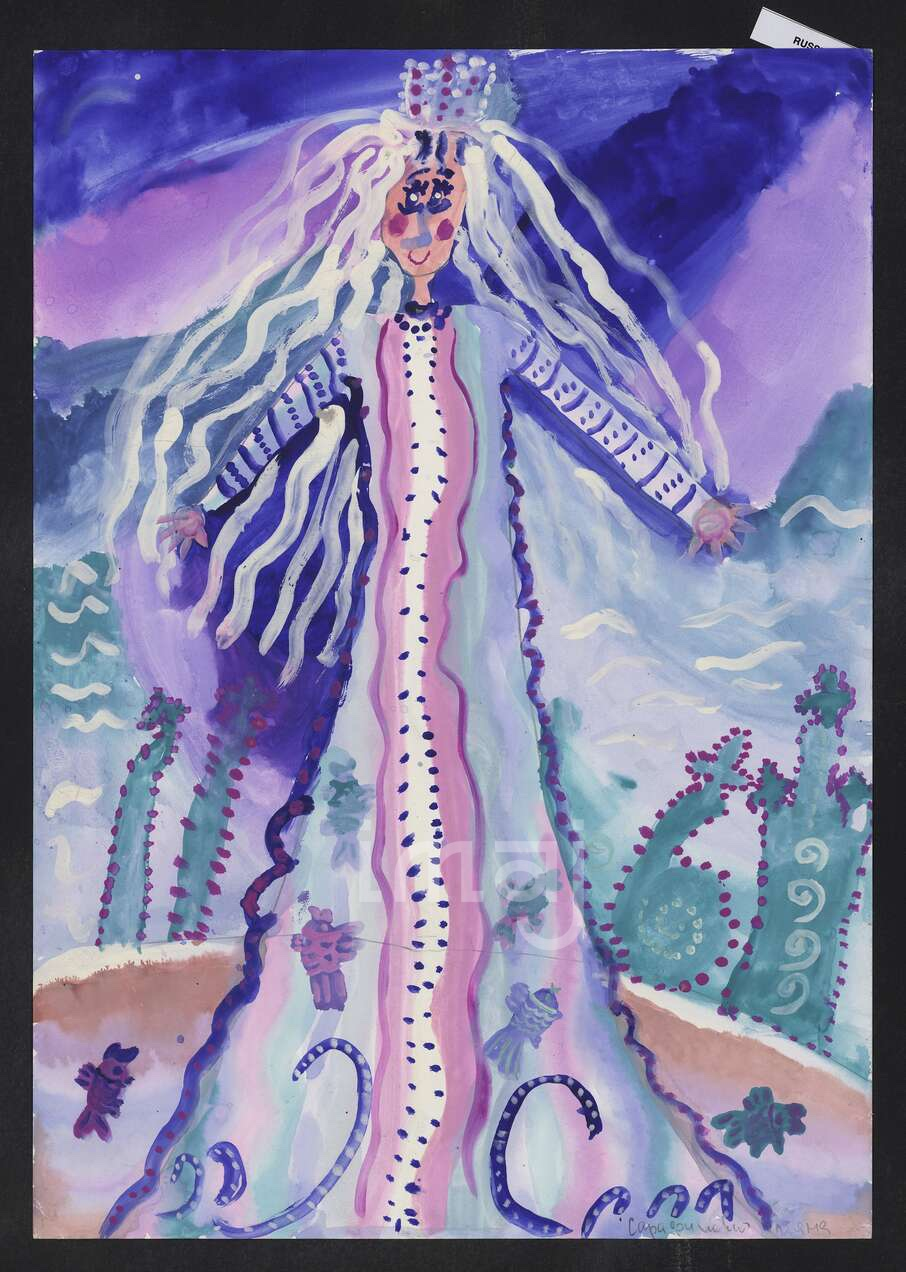

File size: 285998 bytes
Using data URL (no upload).
Image URL preview: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAASABIAAD/4QFWRXhpZgAATU0AKgAAAAgACwEGAAMAAAABAAEAAAEOAAIAAAALAAAAkgEPAAIAAAALAAAAngEQAAIAAAA4AAAAqgESAAMAAAABAAEAAAEaAAUAAAABAAAA4gEbAAUAAAABAAAA6gExAAIAAAAWA...

MODEL RESPONSE:

A woman wearing a white shirt and black skirt is sitting on a chair, with her hands on her lap.


In [ ]:
DATAURL_SIZE_THRESHOLD = 1_000_00
image_path = Path("/Users/eugeniedecaux/Desktop/PDS_mac/dataset_eau/images/train/2017_6-9_0065_RUS_R_C.jpg")
assert image_path.exists(), image_path

display(Image(filename=str(image_path), width=480))
size = image_path.stat().st_size
print("File size:", size, "bytes")



# choose image_url
if size <= DATAURL_SIZE_THRESHOLD:
    print("Using data URL (no upload).")
    image_url = file_to_data_url(image_path)
else:
    print("File too large for data URL, trying upload...")
    try:
        image_url = upload_try(image_path)
    except Exception:
        traceback.print_exc()
        raise

print("Image URL preview:", (image_url[:200] + "...") if len(image_url) > 200 else image_url)

# send to model (plain text message containing the URL)
system_prompt = "You describe the visible content of an image. Answer concisely and factually."
user_text = f"Image: {image_url}\n\nPlease describe what you see in the image."

try:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role":"system","content":system_prompt},
                  {"role":"user","content":user_text}],
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    choice = resp.choices[0]
    msg = getattr(choice, "message", None) or choice
    content = msg.get("content") if isinstance(msg, dict) else getattr(msg, "content", None)
    print("\nMODEL RESPONSE:\n")
    print(content.strip())
    # try parse JSON if applicable
    try:
        parsed = json.loads(content.strip())
        print("\nPARSED JSON:\n", json.dumps(parsed, indent=2, ensure_ascii=False))
    except Exception:
        pass
except Exception:
    traceback.print_exc()

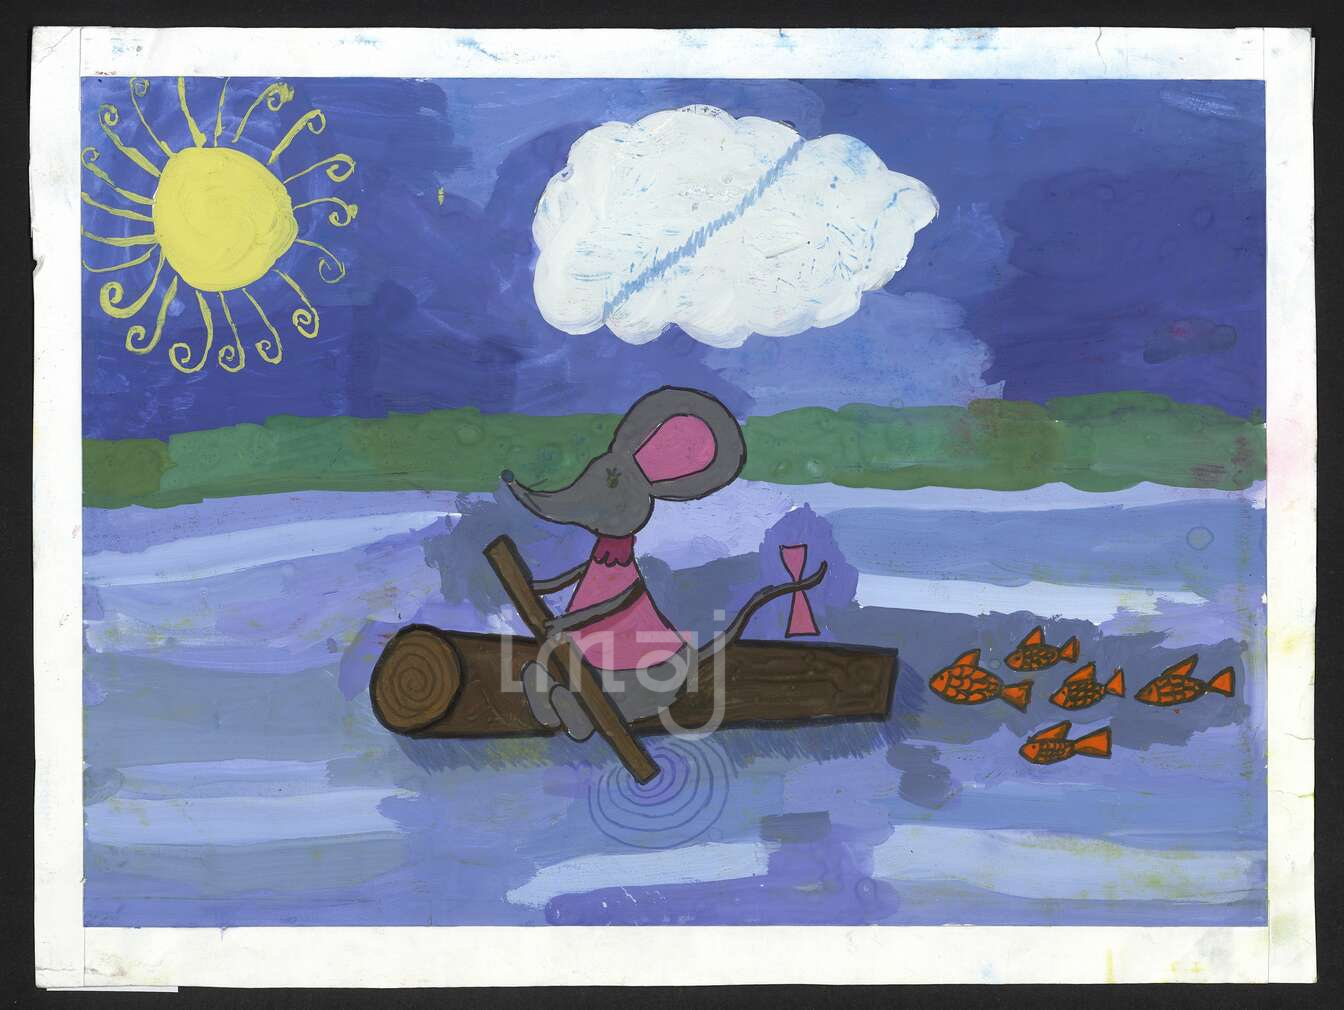

Using data URL (no upload).
Image URL preview: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAASABIAAD/4QFaRXhpZgAATU0AKgAAAAgACwEGAAMAAAABAAEAAAEOAAIAAAAPAAAAkgEPAAIAAAALAAAAogEQAAIAAAA4AAAArgESAAMAAAABAAEAAAEaAAUAAAABAAAA5gEbAAUAAAABAAAA7gExAAIAAAAWA...

MODEL RESPONSE:

A woman wearing a white shirt and black skirt is sitting on a chair, with her hands on her lap and looking directly at the camera.


In [ ]:
image_path = "/Users/eugeniedecaux/Desktop/PDS_mac/dataset_eau/images/train/2017_6-9_0062_RUS_R_C.jpg"

p = Path(image_path)
display(IPImage(filename=str(p), width=480))
size = p.stat().st_size

if size <= DATAURL_SIZE_THRESHOLD:
    print("Using data URL (no upload).")
    image_url = file_to_data_url(p)
else:
    print("File too large for data URL, trying upload...")
    try:
       image_url = upload_try(p)
    except Exception:
        traceback.print_exc()
        raise

print("Image URL preview:", (image_url[:200] + "...") if len(image_url) > 200 else image_url)

# send to model (plain text message containing the URL)
system_prompt = "You describe the visible content of an image. Answer concisely and factually."
user_text = f"Image: {image_url}\n\nPlease describe what you see in the image."

try:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role":"system","content":system_prompt},
                  {"role":"user","content":user_text}],
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    choice = resp.choices[0]
    msg = getattr(choice, "message", None) or choice
    content = msg.get("content") if isinstance(msg, dict) else getattr(msg, "content", None)
    print("\nMODEL RESPONSE:\n")
    print(content.strip())
    # try parse JSON if applicable
    try:
        parsed = json.loads(content.strip())
        print("\nPARSED JSON:\n", json.dumps(parsed, indent=2, ensure_ascii=False))
    except Exception:
        pass
except Exception:
    traceback.print_exc()

# Asking the model to tell the truth

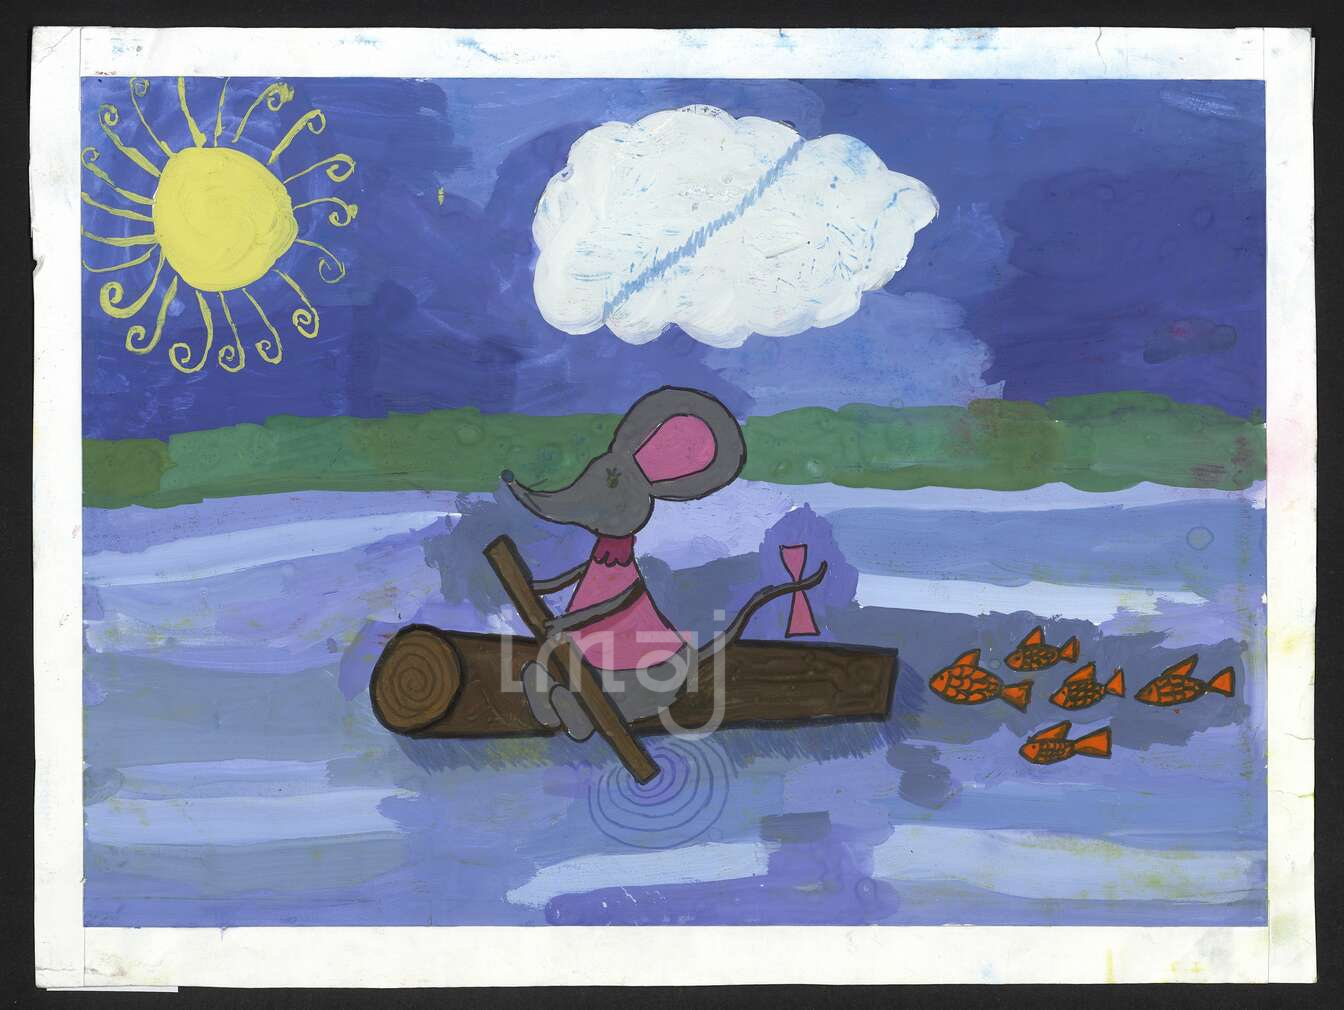

Using data URL (no upload).
Image URL preview: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAASABIAAD/4QFaRXhpZgAATU0AKgAAAAgACwEGAAMAAAABAAEAAAEOAAIAAAAPAAAAkgEPAAIAAAALAAAAogEQAAIAAAA4AAAArgESAAMAAAABAAEAAAEaAAUAAAABAAAA5gEbAAUAAAABAAAA7gExAAIAAAAWA...

MODEL RESPONSE:

Je ne peux pas voir d'image car je suis un modèle de langage basé sur le texte et je n'ai pas la capacité de visualiser ou d'accéder à des images. Cependant, je peux vous aider à décrire une image si vous me fournissez des informations sur son contenu.

Si vous souhaitez me décrire l'image, je peux vous aider à la comprendre ou à l'interpréter. L'image semble être une image encodée en base64, ce qui suggère qu'il s'agit d'une image stockée sous forme de chaîne de caractères. Pour la décrire, il faudrait que je puisse la décoder et l'afficher, ce que je ne peux pas faire.

Si vous pouvez me donner plus de contexte ou me décrire l'image, je serais ravi de vous aider !


In [ ]:

TEMPERATURE = 0.2
MAX_TOKENS = 250
image_path = "/Users/eugeniedecaux/Desktop/PDS_mac/dataset_eau/images/train/2017_6-9_0062_RUS_R_C.jpg"

from pathlib import Path
p = Path(image_path)
assert p.exists(), p
display(IPImage(filename=str(p), width=480))
size = p.stat().st_size

if size <= DATAURL_SIZE_THRESHOLD:
    print("Using data URL (no upload).")
    image_url = file_to_data_url(p)
else:
    print("File too large for data URL, trying upload...")
    try:
       image_url = upload_try(p)
    except Exception:
        traceback.print_exc()
        raise

print("Image URL preview:", (image_url[:200] + "...") if len(image_url) > 200 else image_url)

system_prompt = "Est-ce que tu vois l'image ? Décris-la en plusieurs phrases et ne me mens pas."


user_text = f"Image: {image_url}."

try:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role":"system","content":system_prompt},
                  {"role":"user","content":user_text}],
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    choice = resp.choices[0]
    msg = getattr(choice, "message", None) or choice
    content = msg.get("content") if isinstance(msg, dict) else getattr(msg, "content", None)
    print("\nMODEL RESPONSE:\n")
    print(content.strip())
    # try parse JSON if applicable
    try:
        parsed = json.loads(content.strip())
        print("\nPARSED JSON:\n", json.dumps(parsed, indent=2, ensure_ascii=False))
    except Exception:
        pass
except Exception:
    traceback.print_exc()

# Code to run to locally download the model from huggingface and a vision transfomer to correctly ask for image captioning

In [ ]:
from transformers import AutoProcessor, Llama4ForConditionalGeneration
import torch
import os

model_id = MODEL

# Set the place to cache models
cache = "/Volumes/PortableSSD/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = cache

# ADD YOUR HUGGING FACE TOKEN HERE
os.environ["HF_TOKEN"] = "hf_individual:TOKEN_"  # Replace with your HF token
# Or use: from huggingface_hub import login; login()

# Load processor locally
processor = AutoProcessor.from_pretrained(model_id, cache_dir=cache, token=os.environ.get("HF_TOKEN"))

# Load the model with the token
model = Llama4ForConditionalGeneration.from_pretrained(
    model_id,
    cache_dir=cache,
    torch_dtype=torch.float16,
    token=os.environ.get("HF_TOKEN"),
)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

url1 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg"
url2 = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/datasets/cat_style_layout.png"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": url1},
            {"type": "image", "url": url2},
            {"type": "text", "text": "Can you describe how these two images are similar, and how they differ?"},
        ]
    },
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

# Move inputs to the same device as the model
inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_new_tokens=256,
)

response = processor.batch_decode(outputs[:, inputs["input_ids"].shape[-1]:])[0]
print(response)
print(outputs[0])

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-4-Maverick-17B-128E-Instruct.
401 Client Error. (Request ID: Root=1-695bccec-093c50c95111a4b271282c84;94aac294-d119-46af-9b4e-984dfcc6c11f)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-4-Maverick-17B-128E-Instruct/resolve/main/chat_template.json.
Access to model meta-llama/Llama-4-Maverick-17B-128E-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in.

# Prepomt to test for future work

In [6]:
PREPROMPT = (
    "The input is a drawing-style image.\n"
    "Respond ONLY based on visible shapes, colors, and objects.\n"
    "Do NOT infer intentions, emotions, or any non-visible details.\n"
    "You are an image analysis model.\n"
    "You must answer STRICTLY in valid JSON format.\n"
    "Follow these rules:\n"
    "1. Base your answer ONLY on the visible content of the image. Do NOT infer emotions, intentions, or hidden context.\n"
    "2. Your output MUST be valid JSON. No text before or after the JSON block. No comments, no explanations.\n"
    "3. All values MUST be numeric:\n"
    "    * Binary features -> 0 or 1\n"
    "    * Percentages -> integer between 0 and 100\n"
    "    * Counts -> non-negative integers\n"
    "4. If you are uncertain or the element is not clearly visible, ALWAYS return the lowest numeric value (usually 0).\n"
    "5. Keys must be in snake_case, short, and deterministic.\n"
    "6. Never add sentences, reasoning, or justification. Only return the JSON object.\n"
    "\n"
    "You must ALWAYS output EXACTLY the following JSON object and NOTHING else (replace values as appropriate):\n"
    "{\"character_present\": 0, \"character_count\": 0}\n"
)